# The Challenges with Gradient Descent

Gradient descent looks simple: compute the gradient, take a step downhill,
repeat. On a convex bowl, like linear regression's MSE, this works
beautifully and always finds the global minimum.

Real neural network loss surfaces are **not convex bowls**. They live in
thousands or millions of dimensions and are full of structure that trips up
plain gradient descent:

- **Local minima**: valleys that aren't the lowest point, but look optimal
  from where you're standing.
- **Saddle points**: points that are minima in some directions and maxima in
  others. Far more common than local minima in deep networks.
- **Cliffs & exploding gradients**: regions where the loss is nearly flat,
  then suddenly extremely steep.

Each section below builds a small **toy** loss surface, small enough to
plot, where the problem is easy to see. It then runs plain gradient descent
on that surface so you can watch it struggle.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## 1. Local Minima in the Error Surface

Consider the 1D toy loss

$$L(x) = x^4 - 4x^2 + x$$

This is a "double well": two valleys separated by a hump.

- Because of the `+x` term, the two valleys are **not equally deep**.
- One is the true global minimum.
- The other is only a local minimum that happens to look just as flat and
  "optimal" to a gradient-following algorithm standing inside it.
- Gradient descent only ever looks at the *local* slope, so it has no way of
  knowing whether it is heading toward the deep valley or the shallow one.
- That choice is decided entirely by where it happens to start.

In [4]:
def loss_fn(x):
    return x**4 - 4 * x**2 + x


def grad_descent_1d(x0, lr=0.02, steps=300):
    x = torch.tensor(float(x0), requires_grad=True)
    path = [x.item()]
    for _ in range(steps):
        loss = loss_fn(x)
        loss.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
        path.append(x.item())
    return np.array(path)


# Two pairs of starting points, close together but on opposite sides of the
# hump at x ~= 0.13. A tiny difference in initialization leads to a very
# different outcome.
starts = [-2.5, -0.2, 0.4, 2.5]
paths = {x0: grad_descent_1d(x0) for x0 in starts}

In [ ]:
# paths

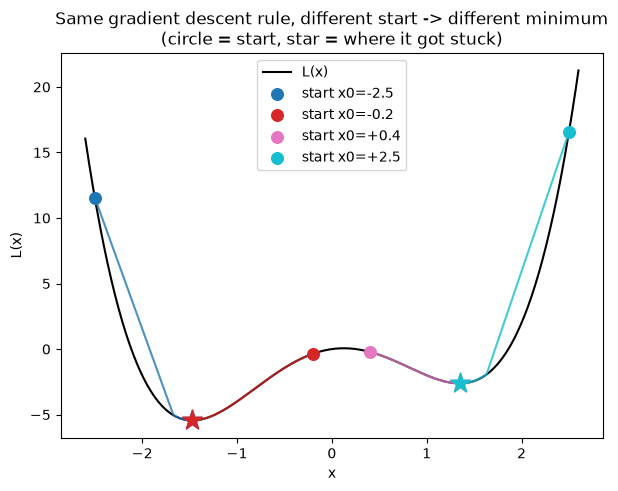

outcome of gradient descent from each starting point:

  x0=-2.5  ->  converged to x=-1.4730,  L(x)=-5.4442
  x0=-0.2  ->  converged to x=-1.4730,  L(x)=-5.4442
  x0=+0.4  ->  converged to x=+1.3470,  L(x)=-2.6186
  x0=+2.5  ->  converged to x=+1.3470,  L(x)=-2.6186

x0=-0.2 and x0=+0.4 start less than 0.6 apart, yet one finds the 
global minimum and the other gets permanently stuck in a local minimum
that is more than twice as bad.


In [5]:
x_plot = np.linspace(-2.6, 2.6, 400)
y_plot = loss_fn(torch.from_numpy(x_plot)).numpy()

plt.figure(figsize=(7, 5))
plt.plot(x_plot, y_plot, color="black", linewidth=1.5, label="L(x)")

colors = plt.cm.tab10(np.linspace(0, 1, len(starts)))
for (x0, path), c in zip(paths.items(), colors):
    path_y = loss_fn(torch.from_numpy(path)).numpy()
    plt.plot(path, path_y, color=c, alpha=0.8)
    plt.scatter(path[0], path_y[0], color=c, marker="o", s=70, zorder=5,
                label=f"start x0={x0:+.1f}")
    plt.scatter(path[-1], path_y[-1], color=c, marker="*", s=220, zorder=5)

plt.xlabel("x")
plt.ylabel("L(x)")
plt.title("Same gradient descent rule, different start -> different minimum\n"
          "(circle = start, star = where it got stuck)")
plt.legend()
plt.show()

print("outcome of gradient descent from each starting point:\n")
for x0, path in paths.items():
    xf = path[-1]
    print(f"  x0={x0:+.1f}  ->  converged to x={xf:+.4f},  L(x)={loss_fn(torch.tensor(xf)).item():.4f}")
print("\nx0=-0.2 and x0=+0.4 start less than 0.6 apart, yet one finds the ")
print("global minimum and the other gets permanently stuck in a local minimum")
print("that is more than twice as bad.")

- `x0=-0.2` and `x0=+0.4` start barely half a unit apart, yet they end up in
  completely different valleys, one nearly **3 points worse** than the
  other.
- Gradient descent has no mechanism to look "over the hill" and check. It is
  purely local, so the quality of the solution it finds depends on luck of
  initialization.
- This is exactly why, in practice, we train with **random restarts**,
  **momentum**, or other tricks that let optimization escape a mediocre
  valley. None of these are visible to plain gradient descent itself.

## 2. Saddle Points: Pesky in Deep Networks

Now a 2D toy loss that has **both** a saddle point and two local (in fact
global) minima, so we can see how they relate:

$$L(x, y) = (x^2 - 1)^2 + y^2$$

- Along $y$, this is just a bowl: $y=0$ is always best.
- Along $x$, it's the same double well as section 1 (without the tilt): a
  hump at $x=0$ and two equal minima at $x=\pm 1$.

That makes $(0, 0)$ a **saddle point**: it curves *up* in the $y$ direction
but *down* in the $x$ direction. Standing exactly there, the surface looks
locally flat-ish in every direction close to it, yet it is neither a
minimum nor a maximum.

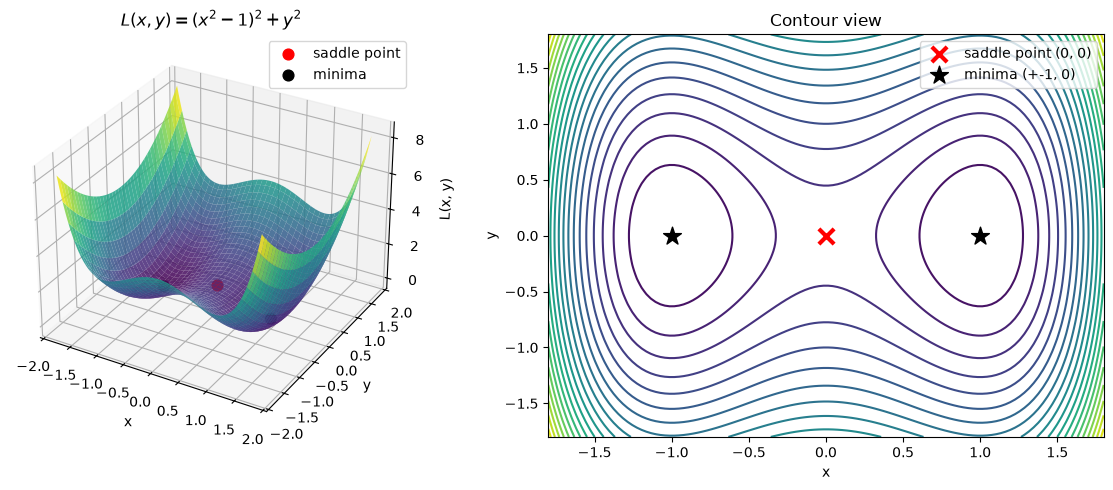

In [6]:
def surface_fn(x, y):
    return (x**2 - 1) ** 2 + y**2


gx = np.linspace(-1.8, 1.8, 120)
gy = np.linspace(-1.8, 1.8, 120)
GX, GY = np.meshgrid(gx, gy)
GZ = surface_fn(GX, GY)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(GX, GY, GZ, cmap="viridis", alpha=0.85, linewidth=0, antialiased=True)
ax1.scatter([0], [0], [surface_fn(0, 0)], color="red", s=60, label="saddle point")
ax1.scatter([-1, 1], [0, 0], [surface_fn(-1, 0), surface_fn(1, 0)],
            color="black", s=60, label="minima")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("L(x, y)")
ax1.set_title("$L(x, y) = (x^2 - 1)^2 + y^2$")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(GX, GY, GZ, levels=25, cmap="viridis")
ax2.scatter([0], [0], color="red", marker="x", s=120, linewidths=3, label="saddle point (0, 0)")
ax2.scatter([-1, 1], [0, 0], color="black", marker="*", s=180, label="minima (+-1, 0)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_title("Contour view")
ax2.legend()
plt.tight_layout()
plt.show()

### Gradient descent crawls near the saddle

- Because the surface is nearly flat right around $(0, 0)$, a gradient
  descent run that starts close to the saddle spends many iterations barely
  moving before suddenly accelerating away toward one of the two minima.
- **Which** minimum it escapes to is again decided by an infinitesimal
  nudge: the sign of $x_0$.

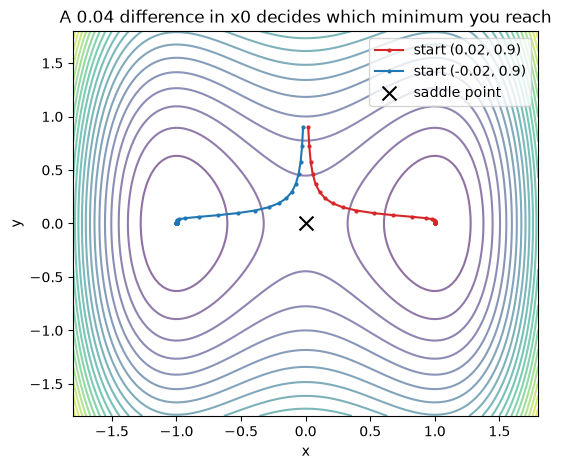

In [7]:
def grad_descent_2d(x0, y0, lr=0.1, steps=120):
    xy = torch.tensor([x0, y0], dtype=torch.float64, requires_grad=True)
    path = [xy.detach().numpy().copy()]
    for _ in range(steps):
        loss = surface_fn(xy[0], xy[1])
        loss.backward()
        with torch.no_grad():
            xy -= lr * xy.grad
        xy.grad.zero_()
        path.append(xy.detach().numpy().copy())
    return np.array(path)


path_pos = grad_descent_2d(0.02, 0.9)
path_neg = grad_descent_2d(-0.02, 0.9)

plt.figure(figsize=(6, 5))
cs = plt.contour(GX, GY, GZ, levels=25, cmap="viridis", alpha=0.6)
plt.plot(path_pos[:, 0], path_pos[:, 1], color="tab:red", marker=".", markersize=4,
          label="start (0.02, 0.9)")
plt.plot(path_neg[:, 0], path_neg[:, 1], color="tab:blue", marker=".", markersize=4,
          label="start (-0.02, 0.9)")
plt.scatter([0], [0], color="black", marker="x", s=100, label="saddle point")
plt.xlabel("x"); plt.ylabel("y")
plt.title("A 0.04 difference in x0 decides which minimum you reach")
plt.legend()
plt.show()

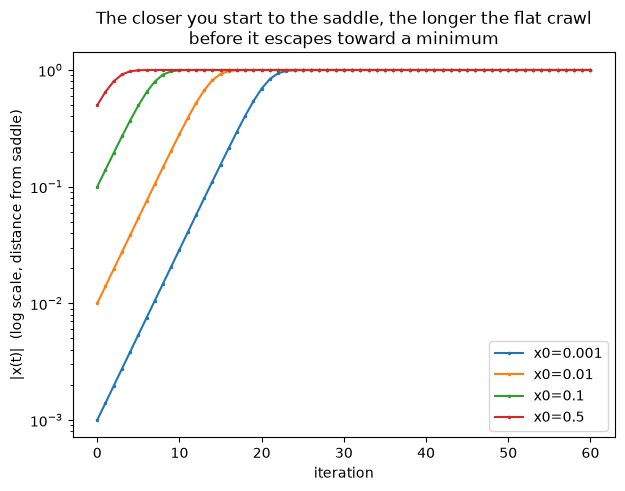

iterations spent with |x| < 0.5 (still 'stuck' near the saddle):
  x0=0.001   -> stuck for 19 of 61 iterations
  x0=0.01    -> stuck for 12 of 61 iterations
  x0=0.1     -> stuck for 6 of 61 iterations
  x0=0.5     -> stuck for 0 of 61 iterations


In [8]:
# Isolate just the x-coordinate crawl: starting exactly on the y=0 line,
# how many iterations does it take to escape the saddle, as a function of
# how close to it we start?
def x_only_descent(x0, lr=0.1, steps=60):
    x = torch.tensor(float(x0), dtype=torch.float64, requires_grad=True)
    path = [x.item()]
    for _ in range(steps):
        loss = (x**2 - 1) ** 2
        loss.backward()
        with torch.no_grad():
            x -= lr * x.grad
        x.grad.zero_()
        path.append(x.item())
    return np.array(path)


plt.figure(figsize=(7, 5))
for x0 in [1e-3, 1e-2, 1e-1, 0.5]:
    path = x_only_descent(x0)
    plt.semilogy(np.abs(path), marker=".", markersize=3, label=f"x0={x0:g}")

plt.xlabel("iteration")
plt.ylabel("|x(t)|  (log scale, distance from saddle)")
plt.title("The closer you start to the saddle, the longer the flat crawl\nbefore it escapes toward a minimum")
plt.legend()
plt.show()

print("iterations spent with |x| < 0.5 (still 'stuck' near the saddle):")
for x0 in [1e-3, 1e-2, 1e-1, 0.5]:
    path = x_only_descent(x0)
    stuck = int(np.sum(np.abs(path) < 0.5))
    print(f"  x0={x0:<7g} -> stuck for {stuck} of {len(path)} iterations")

### Why saddle points, not local minima, dominate in deep networks

- A critical point (where the gradient is zero) is a true local **minimum**
  only if the loss curves *upward* in **every** one of the $n$ parameter
  directions, i.e. every eigenvalue of the Hessian is positive.
- If the sign of each curvature direction were an independent coin flip,
  the probability that *all* of them land positive shrinks exponentially
  with the number of parameters $n$:

$$P(\text{local minimum}) \approx \left(\tfrac12\right)^n$$

- This is a simplified argument, since real Hessians aren't literally
  random coin flips, but it captures a real and now well-documented
  phenomenon (Dauphin et al., 2014).
- In the very high-dimensional loss surfaces of deep networks, it is
  astronomically more likely for a flat critical point to be a **saddle**
  (curving up in some directions, down in others) than a genuine local
  minimum.

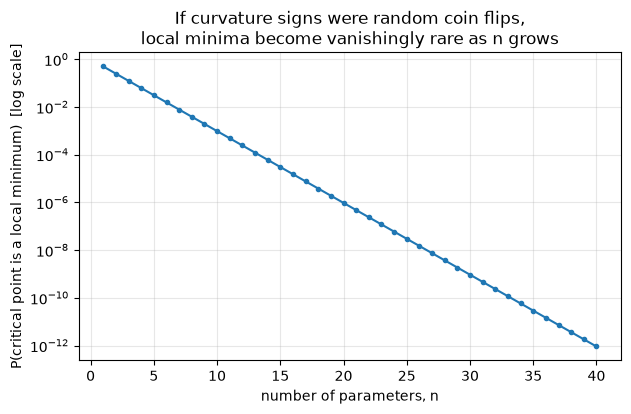

n=       10 parameters  ->  P(local minimum) ~= 0.000977
n=       30 parameters  ->  P(local minimum) ~= 9.31e-10
n=      100 parameters  ->  P(local minimum) ~= 7.89e-31
n=1,000,000 parameters  ->  P(local minimum) ~= 0


In [9]:
dims = np.arange(1, 41)
prob_local_min = 0.5 ** dims.astype(float)

plt.figure(figsize=(7, 4))
plt.semilogy(dims, prob_local_min, marker="o", markersize=3)
plt.xlabel("number of parameters, n")
plt.ylabel("P(critical point is a local minimum)  [log scale]")
plt.title("If curvature signs were random coin flips,\nlocal minima become vanishingly rare as n grows")
plt.grid(True, which="both", alpha=0.3)
plt.show()

for n in [10, 30, 100, 1_000_000]:
    print(f"n={n:>9,} parameters  ->  P(local minimum) ~= {0.5**n:.3g}")

- A modern network easily has millions of parameters, so under this
  argument the odds of a random flat point being a true local minimum are
  effectively zero.
- Almost every flat spot gradient descent encounters in a deep network is a
  **saddle point**. That is exactly why saddle points, not local minima,
  are considered the more practically important obstacle in deep learning.

## 3. Cliffs and Exploding Gradients

- Some loss surfaces have regions that are almost flat, followed by a
  nearly **vertical cliff**.
- This happens naturally whenever a quantity is produced by **repeated
  multiplication**. That is exactly what happens when a recurrent network
  applies, roughly, the same weight $w$ at every timestep.

Toy model of that: unroll a scalar "recurrent" state $h_t = w \cdot h_{t-1}$
for $T$ steps starting from $h_0 = 1$, and use
$L(w) = (h_T - \text{target})^2$ as the loss:

In [10]:
def unroll_loss(w, T=30, h0=1.0, target=0.0):
    h = torch.tensor(h0, dtype=torch.float32)
    for _ in range(T):
        h = w * h
    return (h - target) ** 2

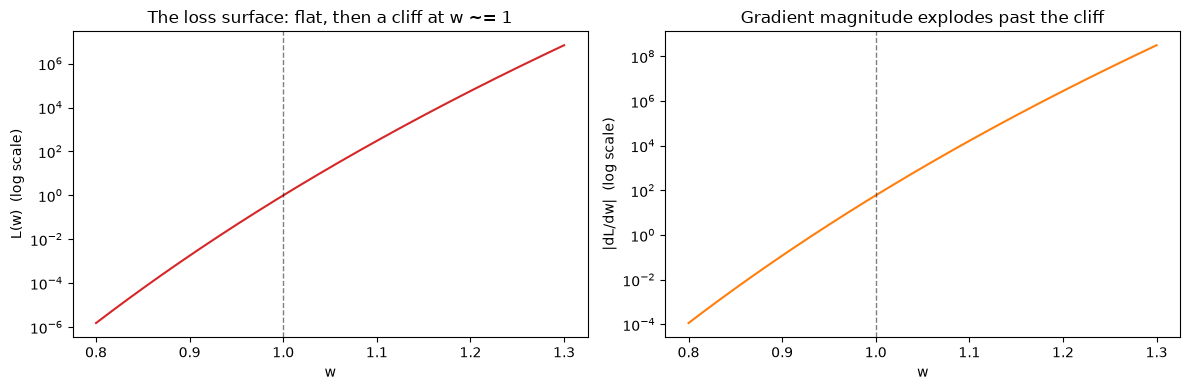

gradient magnitude at a few points:
  w=0.90  |dL/dw| = 0.1198
  w=0.95  |dL/dw| = 2.91
  w=1.00  |dL/dw| = 60
  w=1.05  |dL/dw| = 1067
  w=1.10  |dL/dw| = 1.661e+04
  w=1.15  |dL/dw| = 2.287e+05


In [11]:
ws = np.linspace(0.8, 1.3, 200)
losses, grads = [], []
for wv in ws:
    w = torch.tensor(float(wv), requires_grad=True)
    loss = unroll_loss(w)
    loss.backward()
    losses.append(loss.item())
    grads.append(w.grad.item())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ws, losses, color="tab:red")
axes[0].set_yscale("log")
axes[0].set_xlabel("w"); axes[0].set_ylabel("L(w)  (log scale)")
axes[0].axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
axes[0].set_title("The loss surface: flat, then a cliff at w ~= 1")

axes[1].plot(ws, np.abs(grads), color="tab:orange")
axes[1].set_yscale("log")
axes[1].set_xlabel("w"); axes[1].set_ylabel("|dL/dw|  (log scale)")
axes[1].axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_title("Gradient magnitude explodes past the cliff")

plt.tight_layout()
plt.show()

print("gradient magnitude at a few points:")
for wv in [0.90, 0.95, 1.00, 1.05, 1.10, 1.15]:
    w = torch.tensor(wv, requires_grad=True)
    unroll_loss(w).backward()
    print(f"  w={wv:.2f}  |dL/dw| = {abs(w.grad.item()):.4g}")

- 30 repeated multiplications turn a tiny change in $w$ near 1 into an
  enormous change in gradient magnitude: from about 0.1 at $w=0.9$ to over
  200,000 at $w=1.15$.
- A fixed learning rate that takes sensible steps on the flat part of this
  surface will take a **wildly** oversized step the moment it steps onto
  the cliff.

### Watch it happen: with vs. without gradient clipping

In [12]:
def run_gd(w0, lr, steps, clip_norm=None):
    w = torch.tensor(w0, requires_grad=True)
    history = [w.item()]
    for _ in range(steps):
        loss = unroll_loss(w)
        loss.backward()
        with torch.no_grad():
            grad = w.grad.clone()
            if clip_norm is not None and grad.abs() > clip_norm:
                grad = grad * (clip_norm / grad.abs())
            w -= lr * grad
        w.grad.zero_()
        history.append(w.item())
        if not torch.isfinite(w).item():
            break
    return history


lr = 0.001
unclipped = run_gd(w0=1.1, lr=lr, steps=6)

print("WITHOUT gradient clipping, starting at w=1.1:")
for i, w in enumerate(unclipped):
    print(f"  step {i}: w = {w:.6g}")

WITHOUT gradient clipping, starting at w=1.1:
  step 0: w = 1.1
  step 1: w = -15.5081
  step 2: w = inf


- One step off the flat region lands past the cliff. The next step's
  gradient is so large it sends $w$ to `inf` outright.
- This is exactly what "the loss became NaN" looks like in a real training
  run.

Now the same optimizer and the same learning rate, but with the gradient
**clipped** to a maximum magnitude before each update:

WITH gradient clipping (max |grad| = 5), starting at w=1.1:
  step   0: w = 1.100000   L(w) = 304.482
  step   1: w = 1.095000   L(w) = 231.658
  step   2: w = 1.090000   L(w) = 176.032
  step   5: w = 1.075000   L(w) = 76.6494
  step  10: w = 1.050000   L(w) = 18.6793
  step  50: w = 0.925188   L(w) = 0.00941466
  step 100: w = 0.908172   L(w) = 0.00309094
  step 299: w = 0.888319   L(w) = 0.000820598


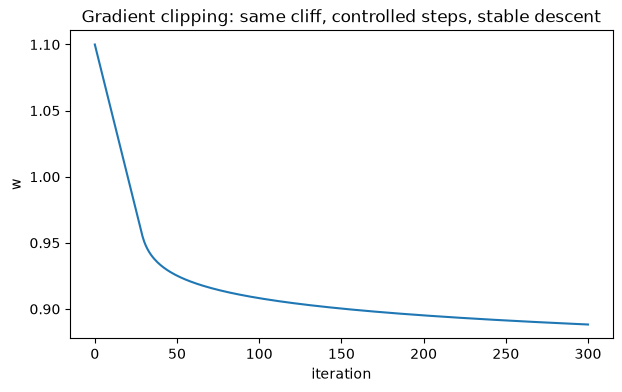

In [13]:
clipped = run_gd(w0=1.1, lr=lr, steps=300, clip_norm=5.0)

checkpoints = [0, 1, 2, 5, 10, 50, 100, 299]
print("WITH gradient clipping (max |grad| = 5), starting at w=1.1:")
for i in checkpoints:
    w = clipped[i]
    print(f"  step {i:3d}: w = {w:.6f}   L(w) = {unroll_loss(torch.tensor(w)).item():.6g}")

plt.figure(figsize=(7, 4))
plt.plot(clipped)
plt.xlabel("iteration")
plt.ylabel("w")
plt.title("Gradient clipping: same cliff, controlled steps, stable descent")
plt.show()

- Same loss surface, same starting point, same learning rate. The *only*
  difference is capping how large a single gradient step is allowed to be.
- That one change is the difference between diverging to `inf` in two steps
  and descending smoothly for 300 steps.
- This is why **gradient clipping** is a standard tool whenever a network's
  computation involves repeated multiplication (RNNs especially, but also
  very deep stacks in general).

## Takeaways

- **Local minima**: gradient descent only follows the local slope, so
  whether it lands in a shallow or a deep valley depends entirely on where
  it starts. The algorithm itself cannot tell the difference. Random
  restarts and momentum-based methods help it escape a mediocre valley.
- **Saddle points**: near a saddle the gradient is small in *some*
  directions but not zero, so descent can crawl for a long time before
  escaping. As the number of parameters grows, the odds that a random flat
  point curves the right way in *every* direction to be a true minimum
  collapse exponentially. So in deep networks, saddle points, not local
  minima, are the far more common obstacle.
- **Cliffs & exploding gradients**: whenever a computation involves
  repeated multiplication (as in unrolled recurrent networks), the loss
  surface can have regions that are flat, then suddenly extremely steep. A
  fixed-size gradient step that is safe on the flat region can be
  catastrophic on the cliff. **Gradient clipping**, which caps the size of
  the update, is a simple, standard fix.
- All three problems share a root cause: gradient descent is a **local**,
  **first-order** method. It only ever sees the slope right where it is
  standing, with no view of the surface further away.